<a href="https://colab.research.google.com/github/keeg2025/DataScienceCapstone25/blob/main/StartingFinalProjectWork.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Importing Data and Libraries

In [2]:
!gdown --id 1zQeXiTV0I2IOKqfiIMz-ntD17dXtb3af -O Airline_Delay_Causes.csv

/usr/local/lib/python3.11/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1zQeXiTV0I2IOKqfiIMz-ntD17dXtb3af
To: /content/Airline_Delay_Causes.csv
100% 23.5M/23.5M [00:00<00:00, 53.8MB/s]


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error

from prophet import Prophet
from prophet.plot import plot_forecast_component

In [5]:
df = pd.read_csv('/content/Airline_Delay_Causes.csv')
df.head()

,year,month,carrier,carrier_name,airport,airport_name,arr_flights,arr_del15,carrier_ct,weather_ct,...,security_ct,late_aircraft_ct,arr_cancelled,arr_diverted,arr_delay,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
0,2024,12,MQ,Envoy Air,EVV,"Evansville, IN: Evansville Regional",61.0,9.0,1.52,1.08,...,0.0,5.84,0.0,0.0,732.0,47.0,90.0,19.0,0.0,576.0
1,2024,12,MQ,Envoy Air,EWR,"Newark, NJ: Newark Liberty International",107.0,42.0,6.01,5.89,...,0.0,4.94,0.0,0.0,2531.0,335.0,491.0,1251.0,0.0,454.0
2,2024,12,MQ,Envoy Air,EYW,"Key West, FL: Key West International",169.0,31.0,3.37,0.71,...,0.0,15.48,5.0,3.0,1596.0,143.0,52.0,468.0,0.0,933.0
3,2024,12,MQ,Envoy Air,FAR,"Fargo, ND: Hector International",171.0,35.0,4.64,2.12,...,0.0,12.92,2.0,0.0,2428.0,245.0,184.0,575.0,0.0,1424.0
4,2024,12,MQ,Envoy Air,FSD,"Sioux Falls, SD: Joe Foss Field",69.0,14.0,2.00,2.47,...,0.0,4.83,1.0,0.0,720.0,86.0,154.0,191.0,0.0,289.0


## Looking at the data

In [6]:
df.describe()

,year,month,arr_flights,arr_del15,carrier_ct,weather_ct,nas_ct,security_ct,late_aircraft_ct,arr_cancelled,arr_diverted,arr_delay,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
count,140875.000000,140875.000000,140586.000000,140348.000000,140586.000000,140586.000000,140586.000000,140586.00000,140586.000000,140586.000000,140586.000000,140586.000000,140586.000000,140586.000000,140586.000000,140586.000000,140586.000000
mean,2021.397516,6.563421,298.141294,54.200138,18.117141,1.999597,14.849566,0.15736,18.984712,6.831036,0.704217,3726.449824,1338.031162,218.773925,715.527912,7.343078,1446.754535
std,1.765894,3.506382,870.094634,161.713315,49.141188,7.340959,51.215436,0.76626,64.781190,44.891064,3.261713,12515.613824,4473.922752,898.655113,2879.914973,42.863965,5294.934873
min,2018.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2020.000000,3.000000,35.000000,5.000000,1.730000,0.000000,0.740000,0.00000,0.970000,0.000000,0.000000,254.000000,78.000000,0.000000,21.000000,0.000000,39.000000
50%,2021.000000,7.000000,82.000000,13.000000,4.975000,0.150000,2.910000,0.00000,3.690000,1.000000,0.000000,816.000000,289.000000,9.000000,108.000000,0.000000,242.000000
75%,2023.000000,10.000000,194.000000,36.000000,13.690000,1.550000,8.540000,0.00000,11.480000,3.000000,0.000000,2355.000000,932.000000,128.000000,351.000000,0.000000,876.000000
max,2024.000000,12.000000,21873.000000,5544.000000,1886.580000,325.410000,1685.740000,58.69000,2588.130000,4951.000000,192.000000,648300.000000,321792.000000,64550.000000,139958.000000,3760.000000,279153.000000


In [7]:
# prompt: can you get me the number of uniques airports in df

# Assuming 'airport' is the column containing airport information
num_unique_airports = df['airport'].nunique()
print(f"Number of unique airports: {num_unique_airports}")


Number of unique airports: 388


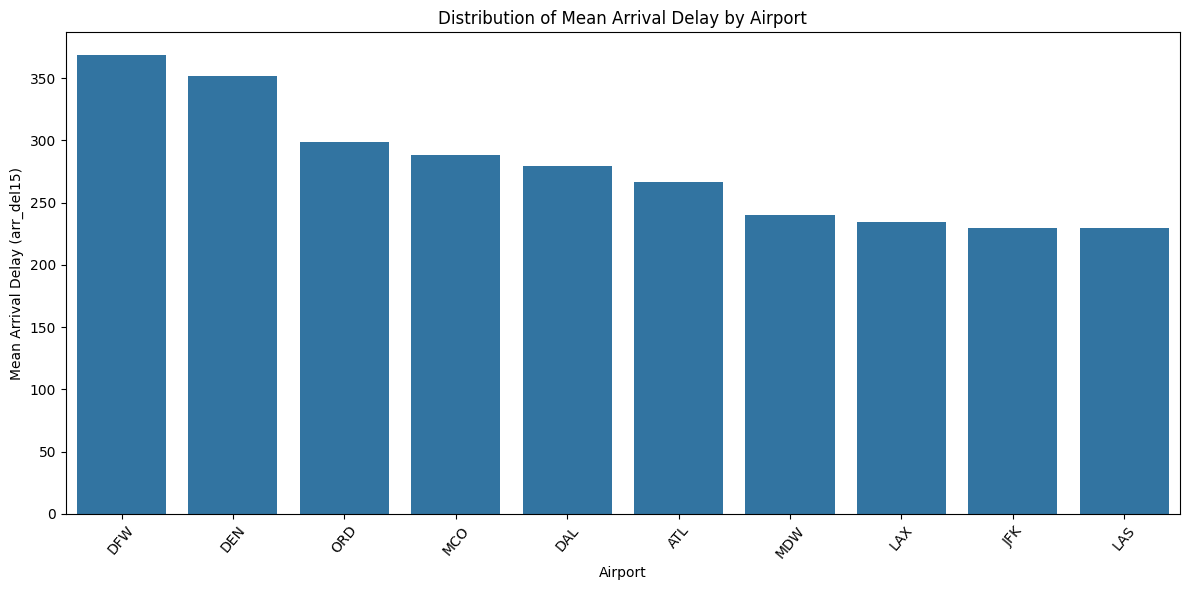

In [8]:
# prompt: make a graph to show the distribution of the arr_del15 by airport (delay #)

import matplotlib.pyplot as plt
import seaborn as sns

# Assuming 'arr_del15' and 'airport' are the relevant columns
# Group the data by airport and calculate the mean of arr_del15
airport_delay_distribution = df.groupby('airport')['arr_del15'].mean()
    #airport_delay_distribution = airport_delay_distribution[(airport_delay_distribution >= 100)]
airport_delay_distribution = airport_delay_distribution.nlargest(10)


# Create a bar plot of the distribution
plt.figure(figsize=(12, 6))
sns.barplot(x=airport_delay_distribution.index, y=airport_delay_distribution.values)
plt.xlabel('Airport')
plt.ylabel('Mean Arrival Delay (arr_del15)')
plt.title('Distribution of Mean Arrival Delay by Airport')
plt.xticks(rotation=50)
plt.tight_layout()
plt.show()


In [9]:
# prompt: subset df by airport = "DEN"

# Subset the DataFrame where the 'airport' column is equal to 'DEN'
den_df = df[df['airport'] == 'DEN']

# Print the subsetted DataFrame
print(den_df.head())

      year  month carrier               carrier_name airport  \
308   2024     12      OO      SkyWest Airlines Inc.     DEN   
628   2024     12      UA   United Air Lines Network     DEN   
746   2024     12      WN         Southwest Airlines     DEN   
1053  2024     12      AA  American Airlines Network     DEN   
1169  2024     12      AS    Alaska Airlines Network     DEN   

                          airport_name  arr_flights  arr_del15  carrier_ct  \
308   Denver, CO: Denver International       5791.0      749.0      404.30   
628   Denver, CO: Denver International       8538.0     1050.0      420.34   
746   Denver, CO: Denver International       7668.0     1320.0      381.48   
1053  Denver, CO: Denver International        726.0      175.0       66.56   
1169  Denver, CO: Denver International        167.0       18.0        4.75   

      weather_ct  ...  security_ct  late_aircraft_ct  arr_cancelled  \
308        67.72  ...         1.56            179.24           36.0   
628 

# Looking at distributions of delay number data

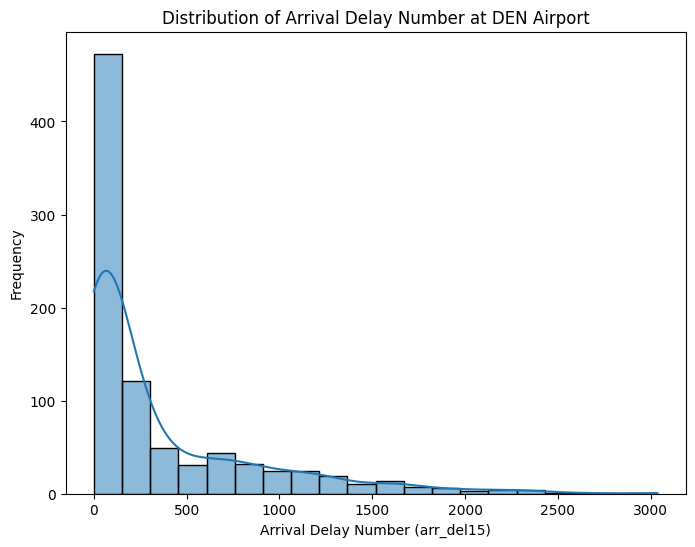

In [10]:
# prompt: can you make a barplot to show the distribution of arr_del15 in the den_df

# Assuming 'arr_del15' is the column you want to analyze in den_df
plt.figure(figsize=(8, 6))
sns.histplot(den_df['arr_del15'], bins=20, kde=True)  # You can adjust the number of bins as needed
plt.xlabel('Arrival Delay Number (arr_del15)')
plt.ylabel('Frequency')
plt.title('Distribution of Arrival Delay Number at DEN Airport')
plt.show()


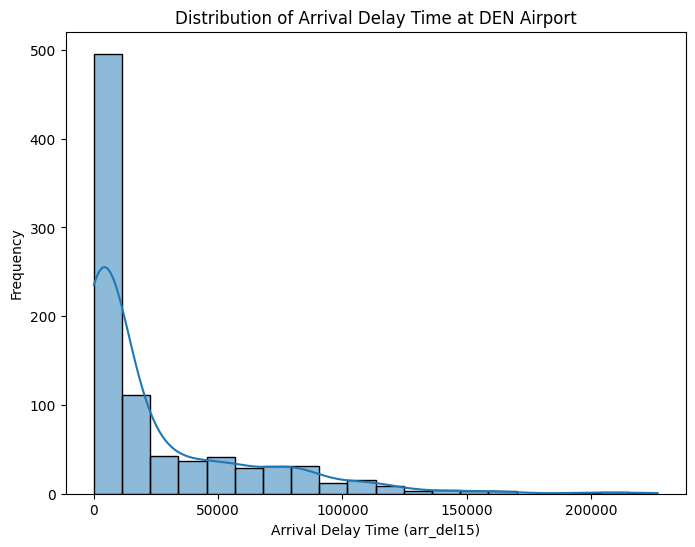

In [11]:
import matplotlib.pyplot as plt
# Assuming 'arr_del15' is the column you want to analyze in den_df
plt.figure(figsize=(8, 6))
sns.histplot(den_df['arr_delay'], bins=20, kde=True)  # You can adjust the number of bins as needed
plt.xlabel('Arrival Delay Time (arr_del15)')
plt.ylabel('Frequency')
plt.title('Distribution of Arrival Delay Time at DEN Airport')
plt.show()


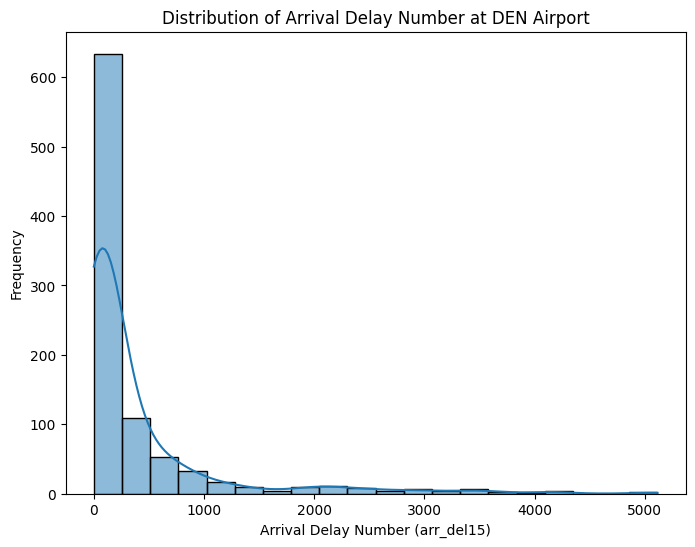

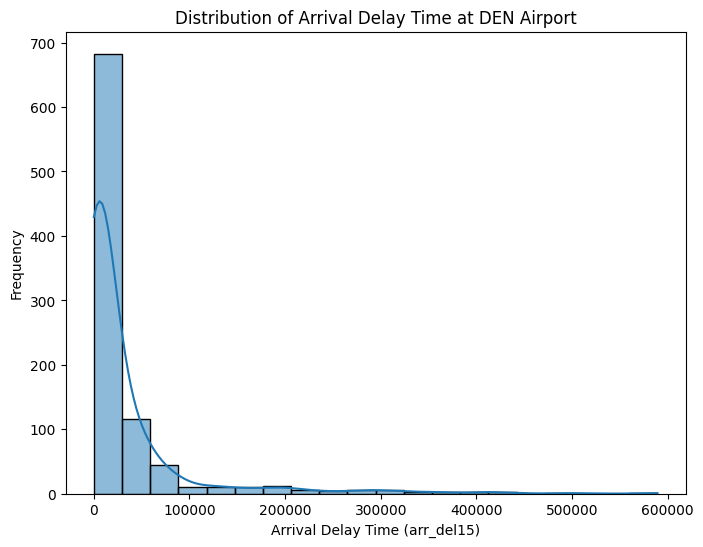

In [12]:
dfw_df = df[df['airport'] == 'DFW']

plt.figure(figsize=(8, 6))
sns.histplot(dfw_df['arr_del15'], bins=20, kde=True)  # You can adjust the number of bins as needed
plt.xlabel('Arrival Delay Number (arr_del15)')
plt.ylabel('Frequency')
plt.title('Distribution of Arrival Delay Number at DEN Airport')
plt.show()

plt.figure(figsize=(8, 6))
sns.histplot(dfw_df['arr_delay'], bins=20, kde=True)  # You can adjust the number of bins as needed
plt.xlabel('Arrival Delay Time (arr_del15)')
plt.ylabel('Frequency')
plt.title('Distribution of Arrival Delay Time at DEN Airport')
plt.show()

## Using frequency to normalize data

In [13]:
# prompt: A value is trying to be set on a copy of a slice from a DataFrame.
# Try using .loc[row_indexer,col_indexer] = value instead

# Use .loc to assign the new column
dfw_df.loc[:, 'del_freq'] = dfw_df['arr_del15'] / dfw_df['arr_flights'] * 100

max_freq_index = dfw_df['del_freq'].idxmax()
df.loc[max_freq_index]

<ipython-input-13-b474cfc1fb39>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfw_df.loc[:, 'del_freq'] = dfw_df['arr_del15'] / dfw_df['arr_flights'] * 100


,952
year,2024
month,12
carrier,9E
carrier_name,Endeavor Air Inc.
airport,DFW
airport_name,"Dallas/Fort Worth, TX: Dallas/Fort Worth Inter..."
arr_flights,2.0
arr_del15,2.0
carrier_ct,0.0
weather_ct,0.0


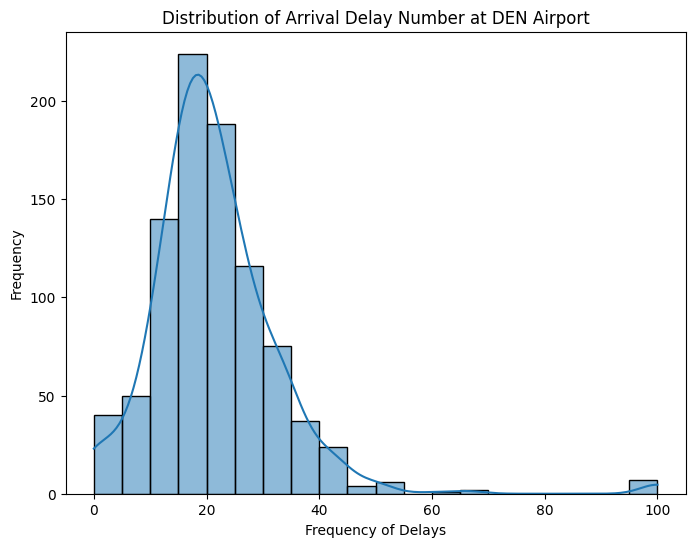

In [14]:
plt.figure(figsize=(8, 6))
sns.histplot(dfw_df['del_freq'], bins=20, kde=True)  # You can adjust the number of bins as needed
plt.xlabel('Frequency of Delays')
plt.ylabel('Frequency')
plt.title('Distribution of Arrival Delay Number at DEN Airport')
plt.show()

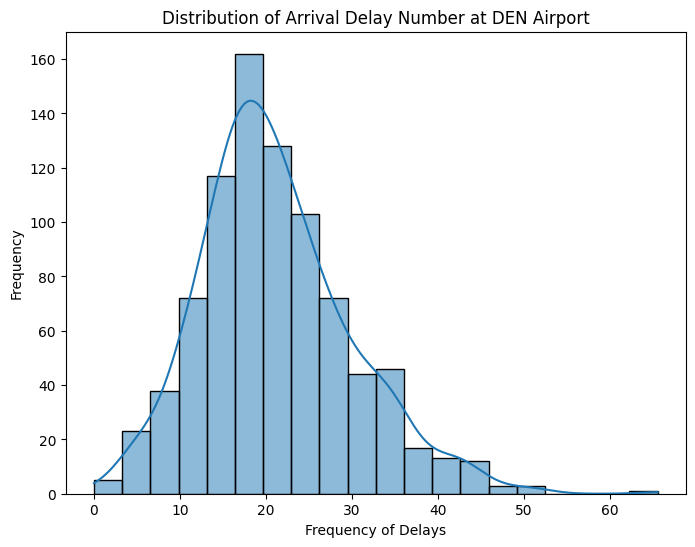

In [15]:
# with a min flight threshold
min_flight_threshold = 10
dfw_df = dfw_df[dfw_df['arr_flights'] > min_flight_threshold]

plt.figure(figsize=(8, 6))
sns.histplot(dfw_df['del_freq'], bins=20, kde=True)  # You can adjust the number of bins as needed
plt.xlabel('Frequency of Delays')
plt.ylabel('Frequency')
plt.title('Distribution of Arrival Delay Number at DEN Airport')
plt.show()

H0 = Is the number of delays (arr_del15) significant to the time of the year(month)?

# Creating data set from top 5 worst airports (df_airports)

In [61]:
# prompt: can you make a new dataframe with airports 'ATL', 'LAX', 'DFW', 'DEN', ORD', and 'JFK'

# Create a list of airports
airports = ['ATL', 'ORD', 'DFW', 'DEN', 'CLT'] # 'LAX', 'JFK']

# Create a new DataFrame containing only the specified airports
df_airports = df[df['airport'].isin(airports)]

# Now you can work with the new DataFrame
print(df_airports.head(1))


    year  month carrier carrier_name airport  \
54  2024     12      MQ    Envoy Air     ORD   

                                 airport_name  arr_flights  arr_del15  \
54  Chicago, IL: Chicago O'Hare International       2518.0      594.0   

    carrier_ct  weather_ct  ...  late_aircraft_ct  arr_cancelled  \
54      151.23       23.28  ...            198.15           10.0   

    arr_diverted  arr_delay  carrier_delay  weather_delay  nas_delay  \
54           2.0    44858.0        15272.0         3736.0     8155.0   

    security_delay  late_aircraft_delay       date  
54            76.0              17619.0 2024-12-01  

[1 rows x 22 columns]


In [17]:
df_airports['date'] = pd.to_datetime(df_airports['year'].astype(str) + '-' + df_airports['month'].astype(str))
df_airports = df_airports[(df_airports['date'] >= '2018-12-01') & (df_airports['date'] <= '2024-12-31')]


<ipython-input-17-8202f90c4f01>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_airports['date'] = pd.to_datetime(df_airports['year'].astype(str) + '-' + df_airports['month'].astype(str))


## Looking at the average delay number

<ipython-input-18-85779de6297d>:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(x='month', y='arr_del15', data=df_airports, ci=None, hue='airport', legend=False)


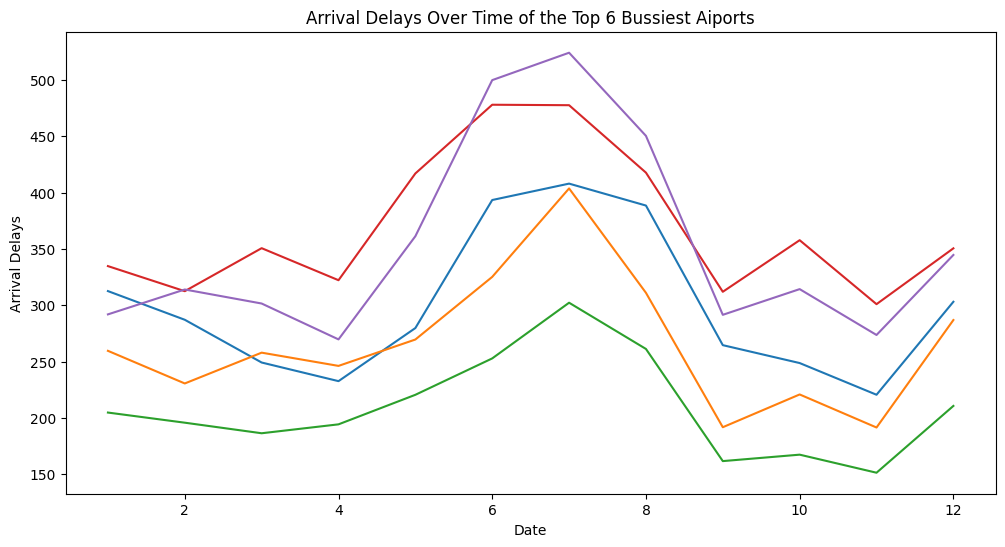

In [18]:
plt.figure(figsize=(12, 6))
sns.lineplot(x='month', y='arr_del15', data=df_airports, ci=None, hue='airport', legend=False)
plt.title('Arrival Delays Over Time of the Top 6 Bussiest Aiports')
plt.xlabel('Date')
plt.ylabel('Arrival Delays')
plt.show()

# Starting Arima by delay number

## original try

In [19]:
# might not need!!

df['date'] = pd.to_datetime(df['year'].astype(str) + '-' + df['month'].astype(str))
df = df[(df['date'] >= '2018-12-01') & (df['date'] <= '2024-12-31')]

# Check structure
print(df.head())
print(df.isnull().sum())

   year  month carrier carrier_name airport  \
0  2024     12      MQ    Envoy Air     EVV   
1  2024     12      MQ    Envoy Air     EWR   
2  2024     12      MQ    Envoy Air     EYW   
3  2024     12      MQ    Envoy Air     FAR   
4  2024     12      MQ    Envoy Air     FSD   

                               airport_name  arr_flights  arr_del15  \
0       Evansville, IN: Evansville Regional         61.0        9.0   
1  Newark, NJ: Newark Liberty International        107.0       42.0   
2      Key West, FL: Key West International        169.0       31.0   
3           Fargo, ND: Hector International        171.0       35.0   
4           Sioux Falls, SD: Joe Foss Field         69.0       14.0   

   carrier_ct  weather_ct  ...  late_aircraft_ct  arr_cancelled  arr_diverted  \
0        1.52        1.08  ...              5.84            0.0           0.0   
1        6.01        5.89  ...              4.94            0.0           0.0   
2        3.37        0.71  ...             15.4

### check stationarity in time series

<ipython-input-20-dea308ce8e4e>:1: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(x='date', y='arr_del15', data=df, ci=None)


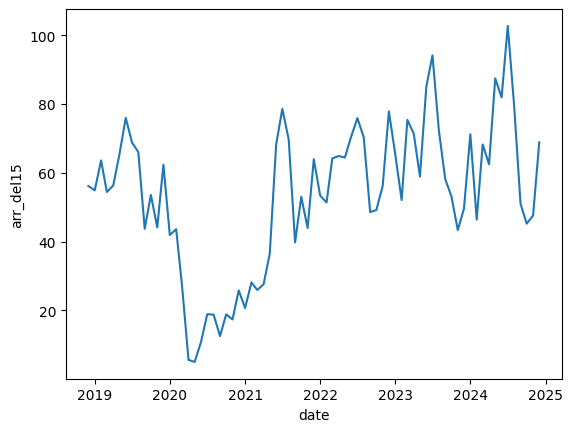

In [20]:
sns.lineplot(x='date', y='arr_del15', data=df, ci=None)
#plt.xticks(rotation=90)
plt.show()

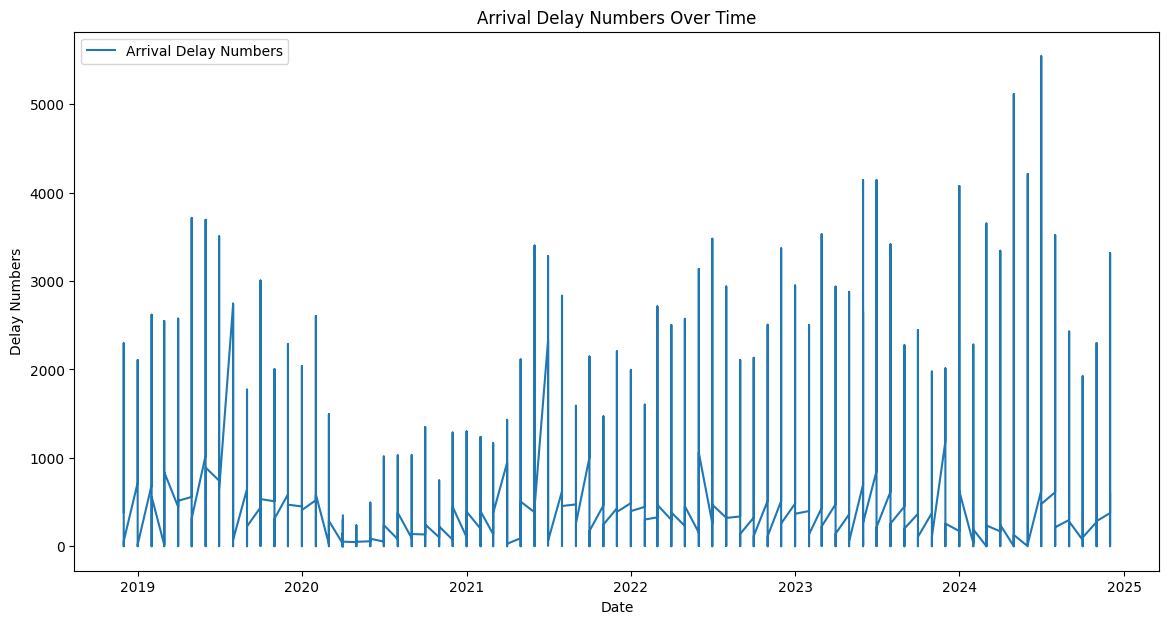

In [21]:
# Plotting the original delay number
plt.figure(figsize=(14, 7))
plt.plot(df_airports['date'], df_airports["arr_del15"], label='Arrival Delay Numbers')
plt.title('Arrival Delay Numbers Over Time')
plt.xlabel('Date')
plt.ylabel('Delay Numbers')
plt.legend()
plt.show()

In [22]:
# Check for NaN or Infinite Values:
print(df_airports["arr_del15"].isnull().sum())  # Check for NaN values
print(np.isinf(df_airports["arr_del15"]).sum())  # Check for infinite values

8
0


In [23]:
# Drop NaN values:
df_airports = df_airports.dropna(subset=["arr_del15"])

# No infinite values to handle (drop)

In [24]:
# Perform the Augmented Dickey-Fuller test on the original series
result_original = adfuller(df_airports["arr_del15"])

print(f"ADF Statistic (Original): {result_original[0]:.4f}")
print(f"p-value (Original): {result_original[1]:.4f}")

if result_original[1] < 0.05:
    print("Interpretation: The original series is Stationary.\n")
else:
    print("Interpretation: The original series is Non-Stationary.\n")

# Apply first-order differencing
df_airports['arr_del_diff'] = df_airports['arr_del15'].diff()

# Perform the Augmented Dickey-Fuller test on the differenced series
result_diff = adfuller(df_airports["arr_del_diff"].dropna())
print(f"ADF Statistic (Differenced): {result_diff[0]:.4f}")
print(f"p-value (Differenced): {result_diff[1]:.4f}")
if result_diff[1] < 0.05:
    print("Interpretation: The differenced series is Stationary.")
else:
    print("Interpretation: The differenced series is Non-Stationary.")


ADF Statistic (Original): -9.3758
p-value (Original): 0.0000
Interpretation: The original series is Stationary.

ADF Statistic (Differenced): -19.9759
p-value (Differenced): 0.0000
Interpretation: The differenced series is Stationary.


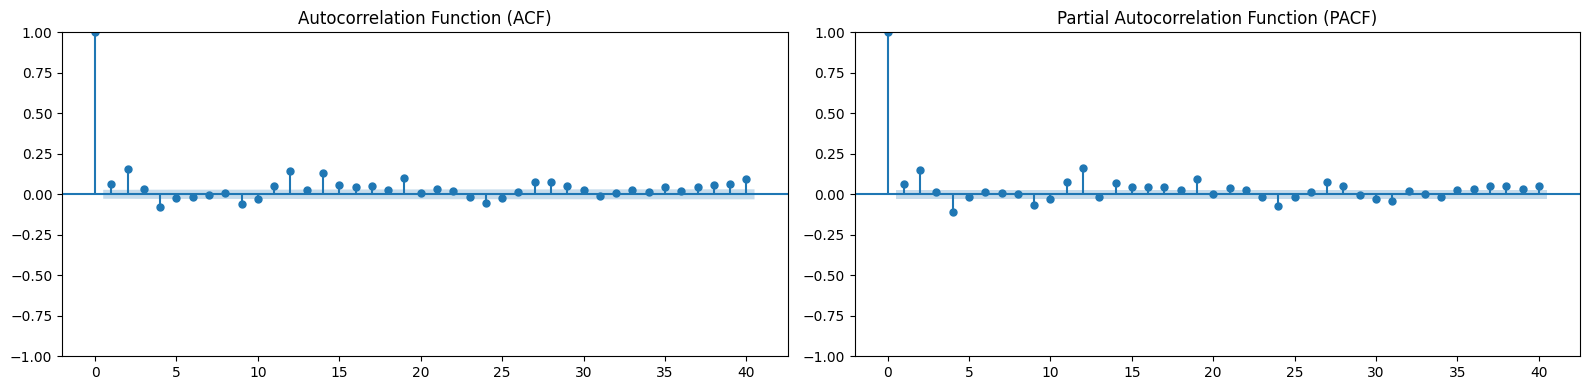

In [25]:
# Plot ACF and PACF for the differenced series
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

# ACF plot
plot_acf(df_airports['arr_del15'].dropna(), lags=40, ax=axes[0])
axes[0].set_title('Autocorrelation Function (ACF)')

# PACF plot
plot_pacf(df_airports['arr_del15'].dropna(), lags=40, ax=axes[1])
axes[1].set_title('Partial Autocorrelation Function (PACF)')

plt.tight_layout()
plt.show()

In [26]:
# Split data into train and test
train_size = int(len(df_airports) * 0.8)
train, test = df_airports.iloc[:train_size], df_airports.iloc[train_size:]

# Fit ARIMA model
model = ARIMA(train["arr_del15"], order=(1,1,1))
model_fit = model.fit()

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


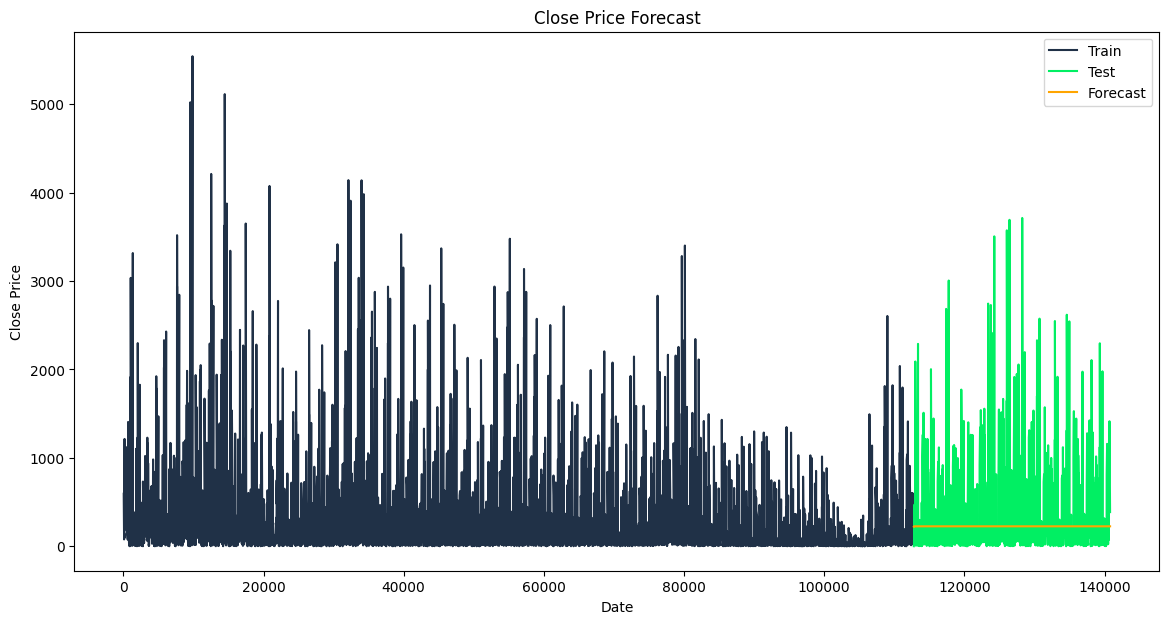

In [27]:
# Forecast
forecast = model_fit.forecast(steps=len(test))

# Plot the results with specified colors
plt.figure(figsize=(14,7))
plt.plot(train.index, train["arr_del15"], label='Train', color='#203147')
plt.plot(test.index, test["arr_del15"], label='Test', color='#01ef63')
plt.plot(test.index, forecast, label='Forecast', color='orange')
plt.title('Close Price Forecast')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.show()


## Set date as the index and use the average delay number

Realized I needed date as an index to make the graph look smoother (closer to our original graph of average flight delay numbers)

### Made a new data set with date as the index and arr_del15 as the average number of flight delays for that month (YYYY-MM)

In [28]:
# prompt: in average_delays can you make the date column the index?

# Group by date and airport, then calculate the mean of 'arr_del15'
average_delays = df_airports.groupby(['date'])['arr_del15'].mean()

# Set the 'date' column as the index
average_delays = average_delays.reset_index()
average_delays = average_delays.set_index('date')

average_delays


,arr_del15
date,
2018-12-01,286.428571
2019-01-01,288.935897
2019-02-01,336.410256
2019-03-01,268.666667
2019-04-01,293.051948
...,...
2024-08-01,476.619048
2024-09-01,328.603175
2024-10-01,269.031250


In [29]:
average_delays.describe()

,arr_del15
count,73.000000
mean,293.541246
std,117.826870
min,31.287879
25%,231.177215
50%,287.000000
75%,368.746269
max,618.718750


### Restarted the Arima with new data set (average_delays)

In [30]:
# Perform the Augmented Dickey-Fuller test on the original series
result_original = adfuller(average_delays["arr_del15"])

print(f"ADF Statistic (Original): {result_original[0]:.4f}")
print(f"p-value (Original): {result_original[1]:.4f}")

if result_original[1] < 0.05:
    print("Interpretation: The original series is Stationary.\n")
else:
    print("Interpretation: The original series is Non-Stationary.\n")


# Apply first-order differencing
average_delays['arr_del_diff'] = average_delays['arr_del15'].diff()

# Perform the Augmented Dickey-Fuller test on the differenced series
result_diff = adfuller(average_delays["arr_del_diff"].dropna())
print(f"ADF Statistic (Differenced): {result_diff[0]:.4f}")
print(f"p-value (Differenced): {result_diff[1]:.4f}")
if result_diff[1] < 0.05:
    print("Interpretation: The differenced series is Stationary.\n")
else:
    print("Interpretation: The differenced series is Non-Stationary.\n")


# Apply second-order differencing
average_delays['arr_del_diff2'] = average_delays['arr_del_diff'].diff()

# Perform the Augmented Dickey-Fuller test on the second differenced series
result_diff = adfuller(average_delays["arr_del_diff2"].dropna())
print(f"ADF Statistic (Differenced): {result_diff[0]:.4f}")
print(f"p-value (Differenced): {result_diff[1]:.4f}")
if result_diff[1] < 0.05:
    print("Interpretation: The second differenced series is Stationary.")
else:
    print("Interpretation: The second differenced series is Non-Stationary.")

ADF Statistic (Original): -1.4239
p-value (Original): 0.5708
Interpretation: The original series is Non-Stationary.

ADF Statistic (Differenced): -1.5595
p-value (Differenced): 0.5039
Interpretation: The differenced series is Non-Stationary.

ADF Statistic (Differenced): -3.2680
p-value (Differenced): 0.0164
Interpretation: The second differenced series is Stationary.


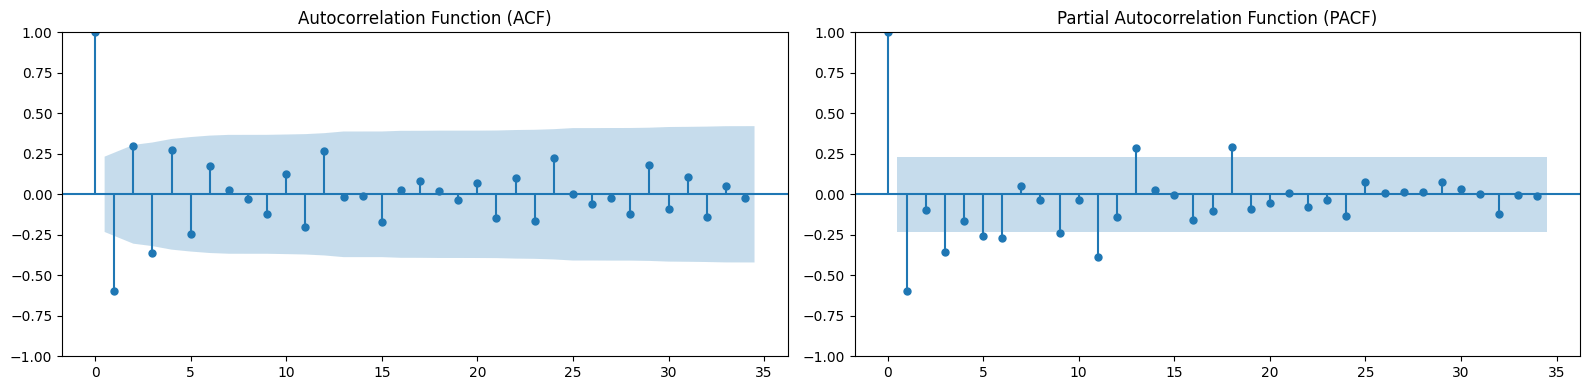

In [31]:
# Plot ACF and PACF for the differenced series
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

# ACF plot
plot_acf(average_delays['arr_del_diff2'].dropna(), lags=34, ax=axes[0])
axes[0].set_title('Autocorrelation Function (ACF)')

# PACF plot
plot_pacf(average_delays['arr_del_diff2'].dropna(), lags=34, ax=axes[1])
axes[1].set_title('Partial Autocorrelation Function (PACF)')

plt.tight_layout()
plt.show()

In [32]:
df_airports.loc[:, 'del_freq'] = df_airports['arr_del15'] / df_airports['arr_flights'] * 100

average_delays['arr_del_freq'] = df_airports.groupby(['date'])['del_freq'].mean()

average_delays

,arr_del15,arr_del_diff,arr_del_diff2,arr_del_freq
date,,,,
2018-12-01,286.428571,NaN,NaN,19.381847
2019-01-01,288.935897,2.507326,NaN,21.128222
2019-02-01,336.410256,47.474359,44.967033,28.152795
2019-03-01,268.666667,-67.743590,-115.217949,18.048826
2019-04-01,293.051948,24.385281,92.128871,21.079025
...,...,...,...,...
2024-08-01,476.619048,-142.099702,-294.666937,25.232673
2024-09-01,328.603175,-148.015873,-5.916171,17.733216
2024-10-01,269.031250,-59.571925,88.443948,14.959779


In [33]:
# Split data into train and test
train_size = int(len(average_delays) * 0.8)
train, test = average_delays.iloc[:train_size], average_delays.iloc[train_size:]

# Fit ARIMA model
model = ARIMA(train["arr_del_diff2"], order=(1,1,1))
model_fit = model.fit()

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


#### Resulting graph of arima model on number of delays

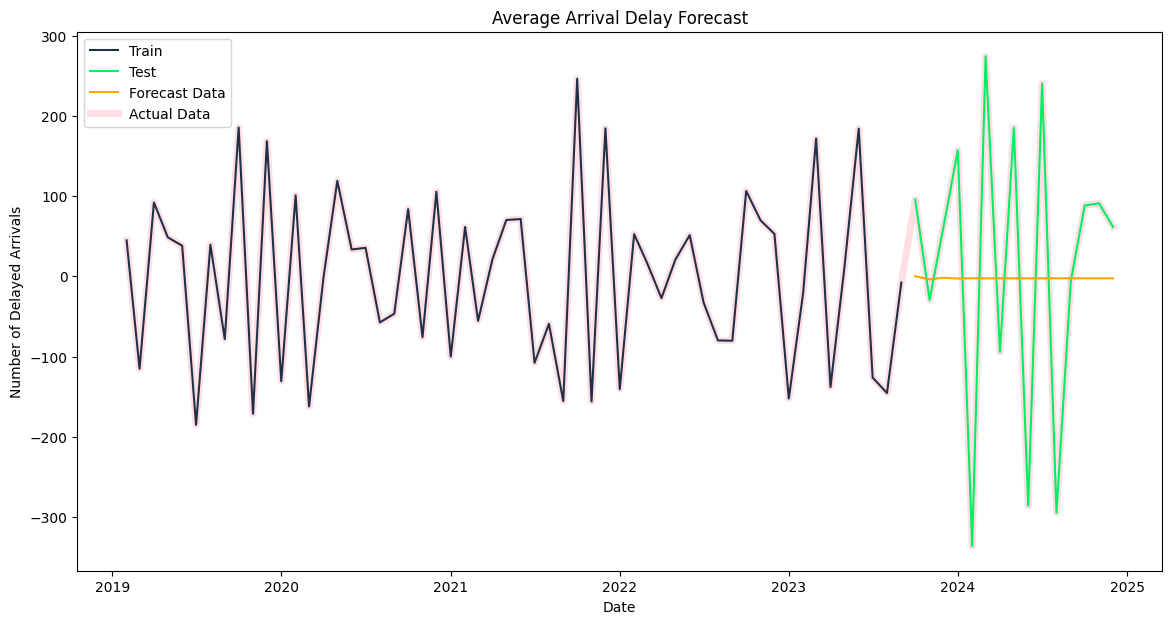

In [34]:
# Forecast
forecast = model_fit.forecast(steps=len(test))

# Plot the results with specified colors
plt.figure(figsize=(14,7))
plt.plot(train.index, train["arr_del_diff2"], label='Train', color='#203147', zorder=2)
plt.plot(test.index, test["arr_del_diff2"], label='Test', color='#01ef63', zorder=3)
plt.plot(test.index, forecast, label='Forecast Data', color='orange', zorder=4)
plt.plot(average_delays.index, average_delays['arr_del_diff2'], label='Actual Data', color='pink', alpha=0.5, linewidth=5, zorder=1)
plt.title('Average Arrival Delay Forecast')
plt.xlabel('Date')
plt.ylabel('Number of Delayed Arrivals')
plt.legend()
plt.show()


#### Graph of average delay numbers without the arima model

<ipython-input-35-8fdcda84e55e>:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(x='date', y='arr_del_diff2', data=average_delays, ci=None)


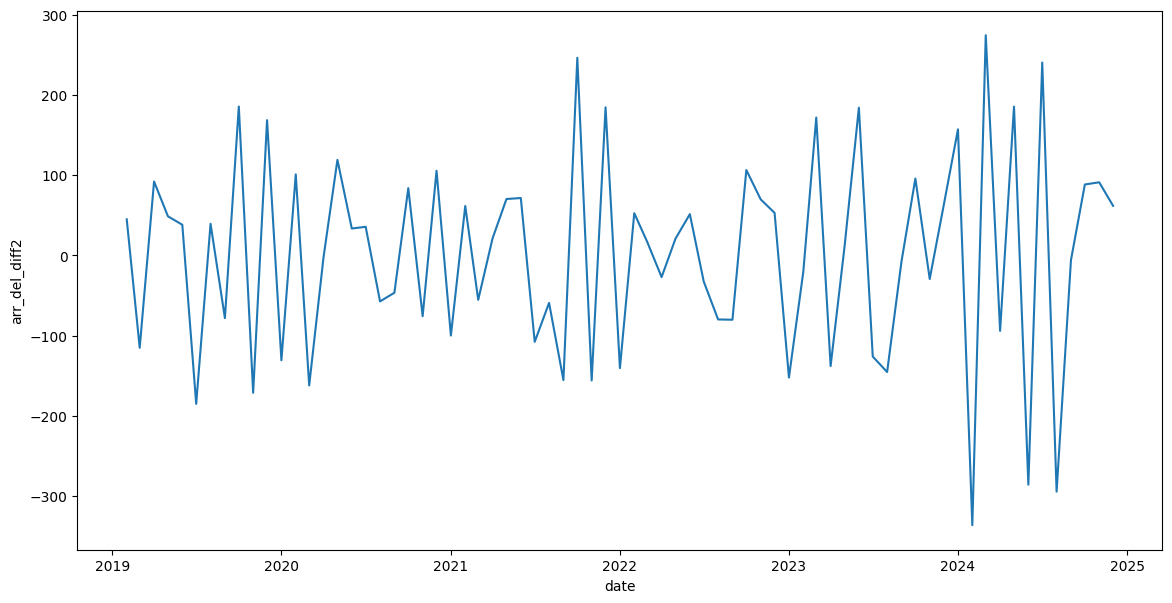

In [35]:
plt.figure(figsize=(14,7))
sns.lineplot(x='date', y='arr_del_diff2', data=average_delays, ci=None)
plt.show()

We check out the AIC and BIC model statistics. Lower values mean the model fits better, but we might also compare the results with those from simpler models to avoid overfitting. I'm printing the numbers here but they make the most sense in the context of comparing to other ARIMA models on the same data, in order to find the ARIMA model that works best.

In [36]:
print(f"AIC: {model_fit.aic}")
print(f"BIC: {model_fit.bic}")

AIC: 681.3795887585728
BIC: 687.5087425620765


We can also evaluate the mean squared error, to assess our model's fit. This is a practical metric. A lower RMSE indicates a better ARIMA model, reflecting smaller differences between actual and predicted values, and it's on the scale of the data.

(example) That is, the RMSE of 118.5339 signifies that, on average, our model's predictions deviate from the actual Close prices by about $118.53.

In our case, the RMSE is 144, meaning the model's predictions deviate from actual delay values by approximately 144 delays on average. Given that the average delay over the total time is around 293.54, this implies the model's predictions could be off by roughly 49%, which suggests room for improvement in accuracy.

In [37]:
forecast = forecast[:len(test)]
test_close = test["arr_del_diff2"][:len(forecast)]

# Calculate RMSE
rmse = np.sqrt(mean_squared_error(test_close, forecast))
print(f"RMSE: {rmse:.4f}")


RMSE: 185.7835


# Arima Model using average minutes of delay by date (YYYY_MM)
(unfinished)

## Making dataset of average delay time

In [38]:
# Group by date and airport, then calculate the mean of 'arr_del15'
average_delay_time = df_airports.groupby(['date'])['arr_delay'].mean()

# Set the 'date' column as the index
average_delay_time = average_delay_time.reset_index()
average_delay_time = average_delay_time.set_index('date')

average_delay_time

,arr_delay
date,
2018-12-01,18405.792208
2019-01-01,21795.987179
2019-02-01,25724.192308
2019-03-01,19440.512821
2019-04-01,23020.545455
...,...
2024-08-01,39251.507937
2024-09-01,22894.396825
2024-10-01,18021.343750


In [39]:
# Check for NaN or Infinite Values:
print(average_delay_time["arr_delay"].isnull().sum())  # Check for NaN values
print(np.isinf(df_airports["arr_delay"]).sum())  # Check for infinite values
# Drop NaN values:
#df_airports = df_airports.dropna(subset=["arr_delay"])

0
0


## Perform the Augmented Dickey-Fuller test on the original series

In [40]:
# Perform the Augmented Dickey-Fuller test on the original series
result_original = adfuller(average_delay_time["arr_delay"])

print(f"ADF Statistic (Original): {result_original[0]:.4f}")
print(f"p-value (Original): {result_original[1]:.4f}")

if result_original[1] < 0.05:
    print("Interpretation: The original series is Stationary.\n")
else:
    print("Interpretation: The original series is Non-Stationary.\n")



# Apply first-order differencing
average_delay_time['arr_delT_diff'] = average_delay_time['arr_delay'].diff()

# Perform the Augmented Dickey-Fuller test on the differenced series
result_diff = adfuller(average_delay_time["arr_delT_diff"].dropna())
print(f"ADF Statistic (Differenced): {result_diff[0]:.4f}")
print(f"p-value (Differenced): {result_diff[1]:.4f}")
if result_diff[1] < 0.05:
    print("Interpretation: The differenced series is Stationary.\n")
else:
    print("Interpretation: The differenced series is Non-Stationary.\n")




# Apply second-order differencing
average_delay_time['arr_delT_diff2'] = average_delay_time['arr_delT_diff'].diff()

# Perform the Augmented Dickey-Fuller test on the second differenced series
result_diff = adfuller(average_delay_time["arr_delT_diff2"].dropna())
print(f"ADF Statistic (Differenced): {result_diff[0]:.4f}")
print(f"p-value (Differenced): {result_diff[1]:.4f}")
if result_diff[1] < 0.05:
    print("Interpretation: The second differenced series is Stationary.")
else:
    print("Interpretation: The second differenced series is Non-Stationary.")

ADF Statistic (Original): -1.2571
p-value (Original): 0.6486
Interpretation: The original series is Non-Stationary.

ADF Statistic (Differenced): -1.5859
p-value (Differenced): 0.4907
Interpretation: The differenced series is Non-Stationary.

ADF Statistic (Differenced): -3.3869
p-value (Differenced): 0.0114
Interpretation: The second differenced series is Stationary.


## Plot ACF and PACF for the differenced series

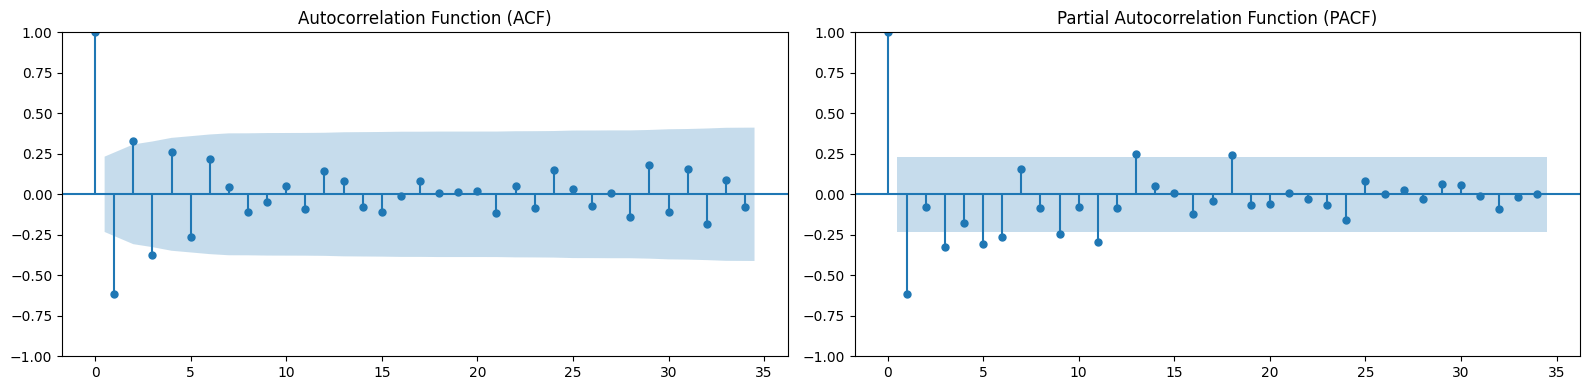

In [41]:
# Plot ACF and PACF for the differenced series
fig, axes = plt.subplots(1, 2, figsize=(16, 4))

# ACF plot
plot_acf(average_delay_time['arr_delT_diff2'].dropna(), lags=34, ax=axes[0])
axes[0].set_title('Autocorrelation Function (ACF)')

# PACF plot
plot_pacf(average_delay_time['arr_delT_diff2'].dropna(), lags=34, ax=axes[1])
axes[1].set_title('Partial Autocorrelation Function (PACF)')

plt.tight_layout()
plt.show()

In [42]:
# Check for NaN or Infinite Values:
print(average_delay_time["arr_delT_diff2"].isnull().sum())  # Check for NaN values
print(np.isinf(average_delay_time["arr_delT_diff2"]).sum())  # Check for infinite values
# Drop NaN values:
average_delay_time = average_delay_time.dropna(subset=["arr_delT_diff2"])

2
0


In [43]:
average_delay_time

,arr_delay,arr_delT_diff,arr_delT_diff2
date,,,
2019-02-01,25724.192308,3928.205128,538.010157
2019-03-01,19440.512821,-6283.679487,-10211.884615
2019-04-01,23020.545455,3580.032634,9863.712121
2019-05-01,29570.605263,6550.059809,2970.027175
2019-06-01,38178.077922,8607.472659,2057.412850
...,...,...,...
2024-08-01,39251.507937,-17844.367063,-36002.348124
2024-09-01,22894.396825,-16357.111111,1487.255952
2024-10-01,18021.343750,-4873.053075,11484.058036


In [44]:
# Split data into train and test
train_size2 = int(len(average_delay_time) * 0.8)
train2, test2 = average_delay_time.iloc[:train_size2], average_delay_time.iloc[train_size2:]

# Fit ARIMA model
model2 = ARIMA(train2["arr_delT_diff2"], order=(1,1,1))
model_fit2 = model2.fit()

/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


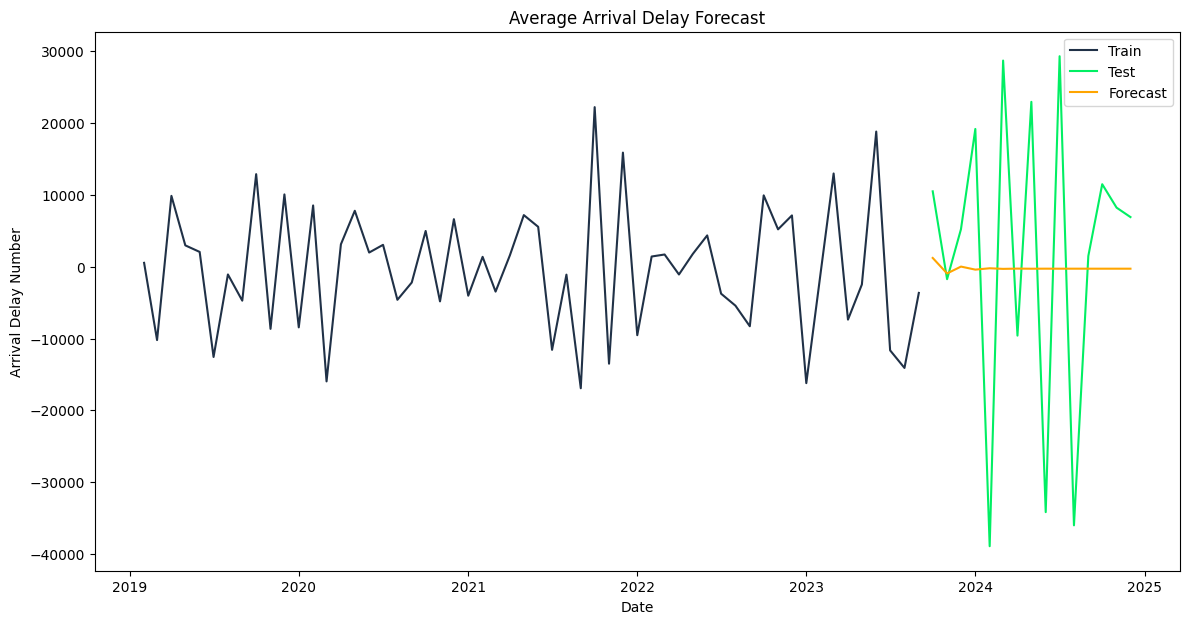

In [45]:
# Forecast
forecast2 = model_fit2.forecast(steps=len(test))

# Plot the results with specified colors
plt.figure(figsize=(14,7))
plt.plot(train2.index, train2["arr_delT_diff2"], label='Train', color='#203147')
plt.plot(test2.index, test2["arr_delT_diff2"], label='Test', color='#01ef63')
plt.plot(test2.index, forecast2, label='Forecast', color='orange')
plt.title('Average Arrival Delay Forecast')
plt.xlabel('Date')
plt.ylabel('Arrival Delay Number')
plt.legend()
plt.show()

In [46]:
print(f"AIC: {model_fit.aic}")
print(f"BIC: {model_fit.bic}")

AIC: 681.3795887585728
BIC: 687.5087425620765


# SARIMA Model

FOund my ARIMA model was under fitting the data and wanted to see if a more seasonal model would work better.

Started with the original average_delays data set and made it into a seasonal data set (4 arr_del15 per year).

In [47]:
# Group by date and airport, then calculate the mean of 'arr_del15'
average_delays_season = df_airports.groupby(['date'])['arr_del15'].mean()

# Set the 'date' column as the index
average_delays_season = average_delays_season.reset_index()
average_delays_season = average_delays_season.set_index('date')

average_delays_season

,arr_del15
date,
2018-12-01,286.428571
2019-01-01,288.935897
2019-02-01,336.410256
2019-03-01,268.666667
2019-04-01,293.051948
...,...
2024-08-01,476.619048
2024-09-01,328.603175
2024-10-01,269.031250


In [48]:
# Assuming average_delays_season already exists
# and has a datetime index and 'arr_del15' column

# Step 1: Define a function to map dates
def map_to_season_start(date):
    year = date.year
    month = date.month
    if month in [1, 2, 3]:
        return pd.Timestamp(year=year, month=1, day=1)
    elif month in [4, 5, 6]:
        return pd.Timestamp(year=year, month=4, day=1)
    elif month in [7, 8, 9]:
        return pd.Timestamp(year=year, month=7, day=1)
    else:  # 10, 11, 12
        return pd.Timestamp(year=year, month=10, day=1)

# Step 2: Apply the function to the index
average_delays_season['season_start'] = average_delays_season.index.map(map_to_season_start)

# Step 3: Group by the new season_start and average arr_del15
average_delays_season_final = average_delays_season.groupby('season_start').mean()

# Step 4 (Optional): Set the new season_start as the index
average_delays_season_final.index.name = 'date'

print(average_delays_season_final)


             arr_del15
date                  
2018-10-01  286.428571
2019-01-01  298.004274
2019-04-01  378.901116
2019-07-01  343.122597
2019-10-01  287.405626
2020-01-01  227.471111
2020-04-01   42.462626
2020-07-01  116.109809
2020-10-01  140.283734
2021-01-01  170.724119
2021-04-01  267.011594
2021-07-01  346.906863
2021-10-01  259.887302
2022-01-01  263.340410
2022-04-01  315.925085
2022-07-01  336.875622
2022-10-01  295.861905
2023-01-01  330.162146
2023-04-01  385.916742
2023-07-01  411.493613
2023-10-01  246.099176
2024-01-01  328.716079
2024-04-01  458.796774
2024-07-01  474.646991
2024-10-01  321.235479


<ipython-input-49-1ba2934bd192>:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(x='date', y='arr_del15', data=average_delays_season_final, ci=None)


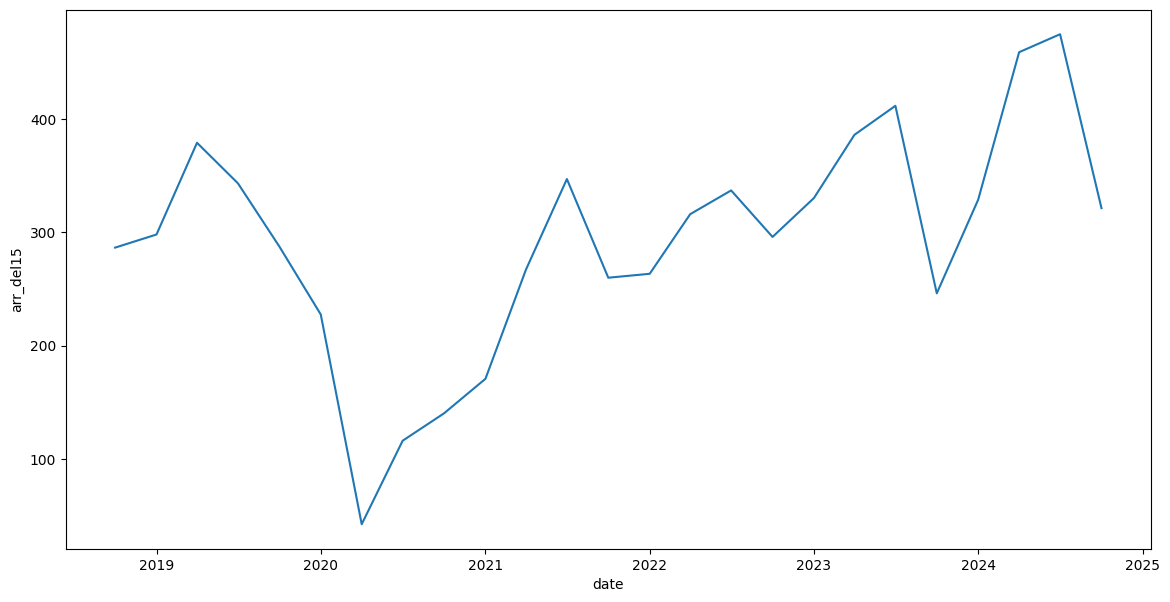

In [49]:
plt.figure(figsize=(14,7))
sns.lineplot(x='date', y='arr_del15', data=average_delays_season_final, ci=None)
plt.show()

In [50]:
def check_stationarity(timeseries):
    # Perform the Dickey-Fuller test
    result = adfuller(timeseries, autolag='AIC')
    p_value = result[1]
    print(f'ADF Statistic: {result[0]}')
    print(f'p-value: {p_value}')
    print('Stationary' if p_value < 0.05 else 'Non-Stationary')


check_stationarity(average_delays_season_final['arr_del15'])


ADF Statistic: -0.01255647642384889
p-value: 0.9574812735558386
Non-Stationary


In [51]:
# Perform the Augmented Dickey-Fuller test on the original series
result_original = adfuller(average_delays_season_final["arr_del15"])

print(f"ADF Statistic (Original): {result_original[0]:.4f}")
print(f"p-value (Original): {result_original[1]:.4f}")

if result_original[1] < 0.05:
    print("Interpretation: The original series is Stationary.\n")
else:
    print("Interpretation: The original series is Non-Stationary.\n")


# Apply first-order differencing
average_delays_season_final['arr_delS_diff'] = average_delays_season_final['arr_del15'].diff()

# Perform the Augmented Dickey-Fuller test on the differenced series
result_diff = adfuller(average_delays_season_final["arr_delS_diff"].dropna())
print(f"ADF Statistic (Differenced): {result_diff[0]:.4f}")
print(f"p-value (Differenced): {result_diff[1]:.4f}")
if result_diff[1] < 0.05:
    print("Interpretation: The differenced series is Stationary.\n")
else:
    print("Interpretation: The differenced series is Non-Stationary.\n")


# Apply second-order differencing
average_delays_season_final['arr_delS_diff2'] = average_delays_season_final['arr_delS_diff'].diff()

# Perform the Augmented Dickey-Fuller test on the second differenced series
result_diff = adfuller(average_delays_season_final["arr_delS_diff2"].dropna())
print(f"ADF Statistic (Differenced): {result_diff[0]:.4f}")
print(f"p-value (Differenced): {result_diff[1]:.4f}")
if result_diff[1] < 0.05:
    print("Interpretation: The second differenced series is Stationary.")
else:
    print("Interpretation: The second differenced series is Non-Stationary.")

ADF Statistic (Original): -0.0126
p-value (Original): 0.9575
Interpretation: The original series is Non-Stationary.

ADF Statistic (Differenced): -1.4150
p-value (Differenced): 0.5751
Interpretation: The differenced series is Non-Stationary.

ADF Statistic (Differenced): -4.1208
p-value (Differenced): 0.0009
Interpretation: The second differenced series is Stationary.


In [52]:
average_delays_season = average_delays_season_final['arr_delS_diff2'].dropna()
print(average_delays_season)

date
2019-04-01     69.321141
2019-07-01   -116.675362
2019-10-01    -19.938452
2020-01-01     -4.217543
2020-04-01   -125.073970
2020-07-01    258.655667
2020-10-01    -49.473257
2021-01-01      6.266459
2021-04-01     65.847090
2021-07-01    -16.392206
2021-10-01   -166.914830
2022-01-01     90.472669
2022-04-01     49.131567
2022-07-01    -31.634138
2022-10-01    -61.964254
2023-01-01     75.313958
2023-04-01     21.454355
2023-07-01    -30.177726
2023-10-01   -190.971307
2024-01-01    248.011339
2024-04-01     47.463792
2024-07-01   -114.230478
2024-10-01   -169.261729
Name: arr_delS_diff2, dtype: float64


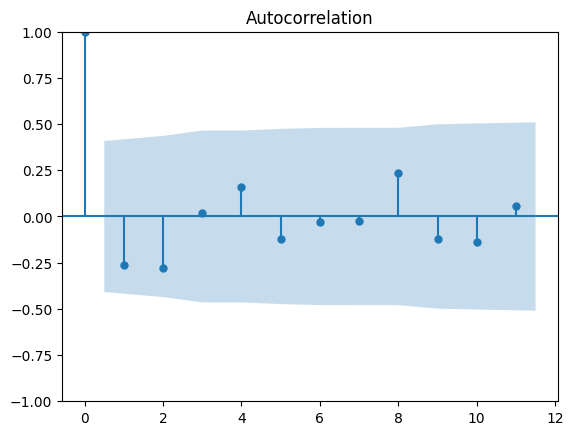

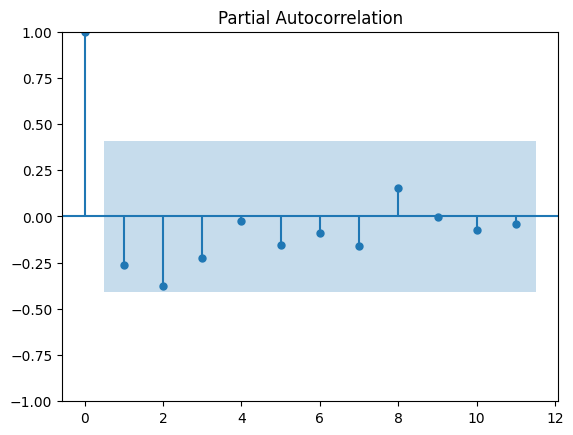

In [53]:
# Plot ACF and PACF
plot_acf(average_delays_season)
plot_pacf(average_delays_season)
plt.show()

In [54]:
# Define SARIMA parameters
p, d, q = 1, 1, 1
P, D, Q, s = 1, 1, 1, 4  # Assuming seasonal seasonality

# Fit the SARIMA model
model = SARIMAX(average_delays_season, order=(p, d, q), seasonal_order=(P, D, Q, s))
results = model.fit()
model


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency QS-OCT will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:997: UserWarning: Non-stationary starting seasonal autoregressive Using zeros as starting parameters.
  warn('Non-stationary starting seasonal autoregressive'
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/statespace/sarimax.py:1009: UserWarning: Non-invertible starting seasonal moving average Using zeros as starting parameters.
  warn('Non-invertible starting seasonal moving average'


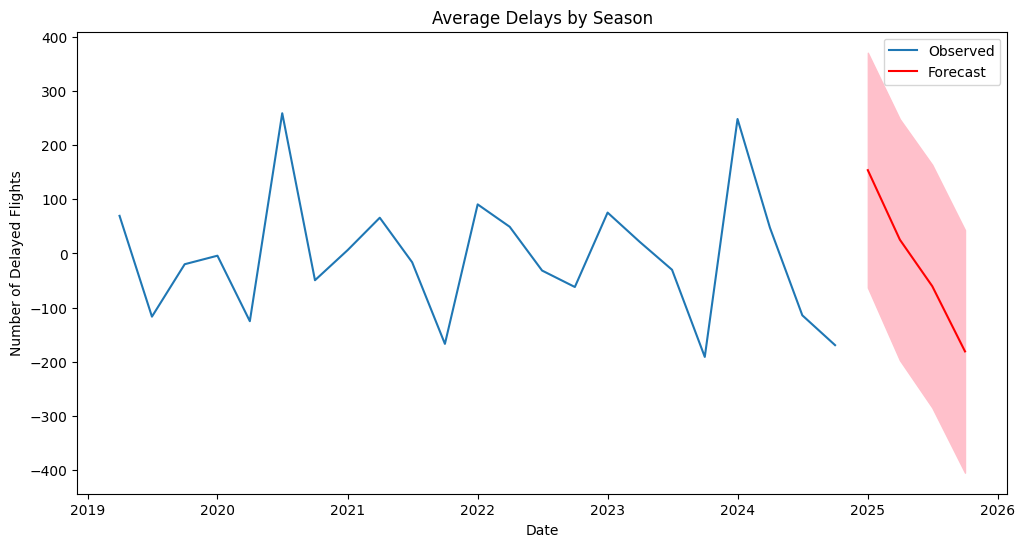

In [55]:
# Forecast future values
forecast_periods = 4  # Forecast the next 12 months
forecast = results.get_forecast(steps=forecast_periods)
forecast_mean = forecast.predicted_mean
forecast_ci = forecast.conf_int()

# Plot the forecast
plt.figure(figsize=(12, 6))
plt.plot(average_delays_season, label='Observed')
plt.plot(forecast_mean, label='Forecast', color='red')
plt.fill_between(forecast_ci.index, forecast_ci.iloc[:, 0], forecast_ci.iloc[:, 1], color='pink')
plt.title("Average Delays by Season")
plt.xlabel("Date")
plt.ylabel("Number of Delayed Flights")
plt.legend()
plt.show()


In [56]:
observed = average_delays_season[-forecast_periods:]
mae = mean_absolute_error(observed, forecast_mean)
mse = mean_squared_error(observed, forecast_mean)
print(f'MAE: {mae}')
print(f'MSE: {mse}')

MAE: 45.445024348254385
MSE: 3104.5172550301522


MAE = 45.45 means your predictions (or model) are typically about 45.45 off from the actual arr_delS_diff2 values (number of delays).

MSE = 3104.52 (mean squared error) The average squared error is 3104.52 units²

For both, being bigger is worse

# Prophet Model

In [57]:
# If a 'date' column does not exist, create it from 'year' and 'month'
if 'date' not in df_airports.columns:
    # Assume day 1 for each month
    df_airports['date'] = pd.to_datetime(df_airports[['year', 'month']].assign(day=1))
else:
    df_airports['date'] = pd.to_datetime(df_airports['date'])


df_airports['date']
#df_airports

,date
54,2024-12-01
95,2024-12-01
106,2024-12-01
108,2024-12-01
127,2024-12-01
...,...
140586,2018-12-01
140601,2018-12-01
140602,2018-12-01
140708,2018-12-01


In [58]:
# Organize the data by date
prophet_data = df_airports.groupby('date')['arr_del15'].mean().reset_index()
prophet_data.index = prophet_data.index + 1  # Set index starting from 1
prophet_data.index.name = 'Index' # optional: name the index column for better clarity
prophet_data.columns = ['ds', 'y']  # Rename columns for Prophet
prophet_data

,ds,y
Index,,
1,2018-12-01,286.428571
2,2019-01-01,288.935897
3,2019-02-01,336.410256
4,2019-03-01,268.666667
5,2019-04-01,293.051948
...,...,...
69,2024-08-01,476.619048
70,2024-09-01,328.603175
71,2024-10-01,269.031250


In [59]:
prophet_data['y'].describe()

,y
count,73.000000
mean,293.541246
std,117.826870
min,31.287879
25%,231.177215
50%,287.000000
75%,368.746269
max,618.718750


INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpyvwi533j/a9uq6jqh.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpyvwi533j/kmt31_uz.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=52816', 'data', 'file=/tmp/tmpyvwi533j/a9uq6jqh.json', 'init=/tmp/tmpyvwi533j/kmt31_uz.json', 'output', 'file=/tmp/tmpyvwi533j/prophet_modelq44u0tmi/prophet_model-20250501155142.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
15:51:42 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
15:51:43 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


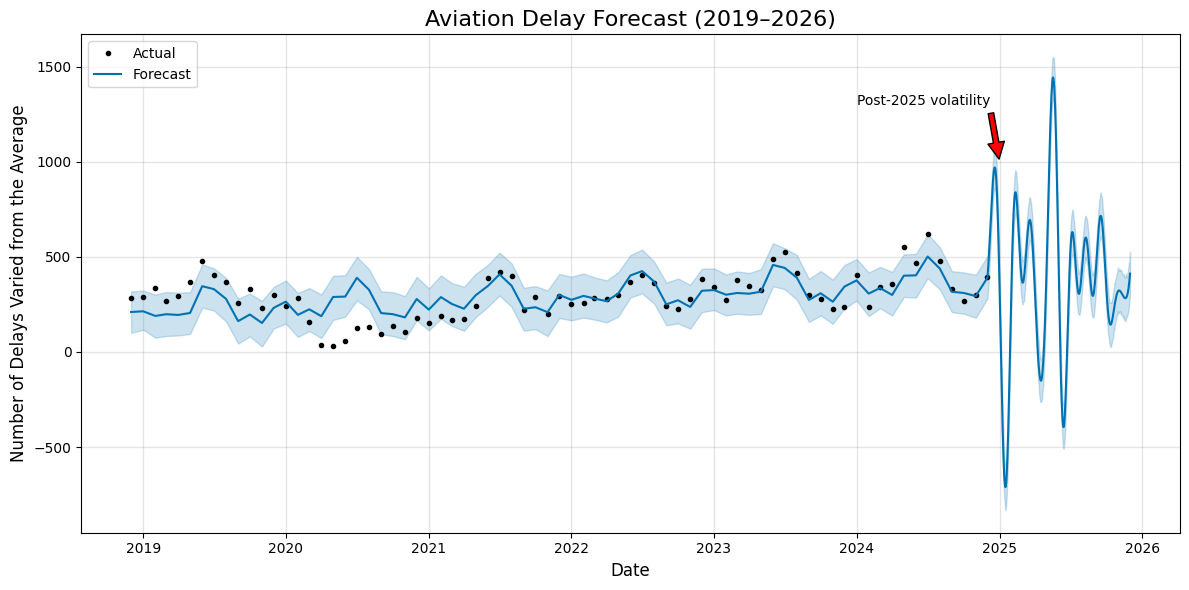

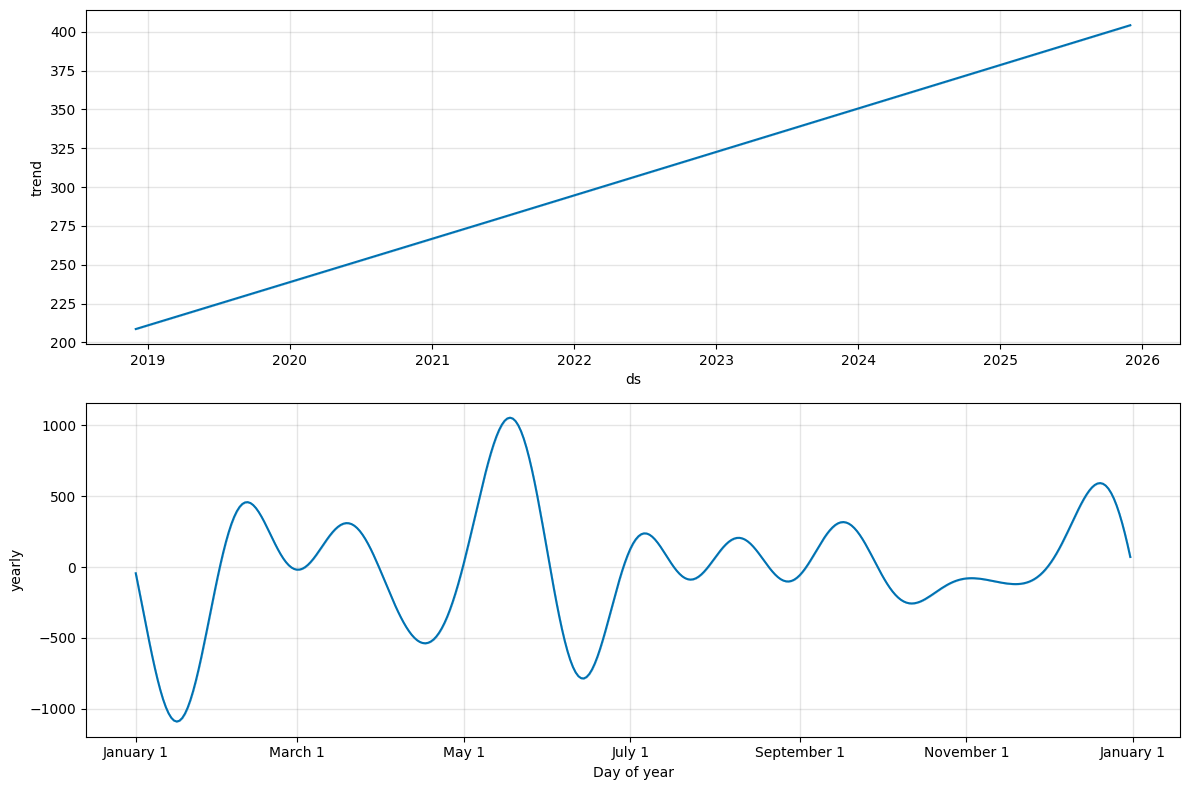

In [86]:
# 1. Prepare your data
# Completed above
# Prophet expects two columns: ds (date) and y (value)

# 2. Initialize and fit the model
m = Prophet()
m.fit(prophet_data)

# 3. Make future dataframe
future = m.make_future_dataframe(periods=365)  # forecast 90 days into the future

# 4. Predict
forecast = m.predict(future)

# 5. Plot
fig1 = m.plot(forecast)
ax = fig1.gca()
ax.set_title("Aviation Delay Forecast (2019–2026)", fontsize=16)
ax.set_xlabel("Date", fontsize=12)
ax.set_ylabel("Number of Delays Varied from the Average", fontsize=12)
ax.grid(True)
fig1.set_size_inches(12, 6)
plt.tight_layout()
ax.legend(["Actual", "Forecast"], loc='upper left', fontsize=10)
ax.annotate("Post-2025 volatility", xy=(pd.to_datetime('2025-01-01'), 1000),
            xytext=(pd.to_datetime('2024-01-01'), 1300),
            arrowprops=dict(facecolor='red', shrink=0.05),
            fontsize=10)
plt.show()

fig2 = m.plot_components(forecast)
fig2.set_size_inches(12, 8)
plt.tight_layout()
plt.show()


Thanks for sharing the Prophet model output! Here's an explanation of each plot based on your aviation delay data:

---

### **First Image (Forecast Plot)**
This plot shows the **forecasted values of aviation delays** over time.

- **X-axis (`ds`)**: Date (from 2019 to 2026).
- **Y-axis (`y`)**: Value of the target variable (aviation delay numbers).
- **Black dots**: Actual observed delay data.
- **Dark blue line**: Prophet's forecasted trend.
- **Light blue shaded area**: Uncertainty interval (usually 80% or 95% confidence).
- **Right side of plot (2025 onward)**: High volatility in forecasts, possibly due to:
  - Missing or sparse data in later years.
  - Anomalies in recent observations.
  - Model overfitting or high sensitivity to recent fluctuations.

---

### **Second Image (Trend and Seasonality Components)**

#### **Top plot: `trend`**
- Represents the **underlying growth pattern** in aviation delays over time.
- A steady **increase** from 2019 to 2026 suggests that average delays are rising over time.

#### **Bottom plot: `yearly`**
- Displays the **yearly seasonality** in delays:
  - Peaks and troughs indicate **predictable patterns** that repeat annually.
  - For instance:
    - High delays around **May–July** and **December** (likely due to increased travel).
    - Lower delays in **January** and **late fall**.
  - These patterns can reflect seasonal travel spikes and weather-related disruptions.

---

### **Summary**
- **Delays are generally increasing** over time.
- There are **clear seasonal patterns**, with delays peaking mid-year and around holidays.
- **Uncertainty increases significantly** beyond early 2025, which could signal model instability or future unpredictability in the data.

Would you like help improving this forecast or diagnosing the volatility after 2025?

# Prophet Model on frequenxy and top 5 worst aiports based on frequency


In [66]:
airports1 = ['SJU', 'PBI', 'EWR', 'LAS', 'FLL']

# Create a new DataFrame containing only the specified airports
airport_BFreq = df[df['airport'].isin(airports1)]

# Now you can work with the new DataFrame
print(airport_BFreq.head(1))

   year  month carrier carrier_name airport  \
1  2024     12      MQ    Envoy Air     EWR   

                               airport_name  arr_flights  arr_del15  \
1  Newark, NJ: Newark Liberty International        107.0       42.0   

   carrier_ct  weather_ct  ...  late_aircraft_ct  arr_cancelled  arr_diverted  \
1        6.01        5.89  ...              4.94            0.0           0.0   

   arr_delay  carrier_delay  weather_delay  nas_delay  security_delay  \
1     2531.0          335.0          491.0     1251.0             0.0   

   late_aircraft_delay       date  
1                454.0 2024-12-01  

[1 rows x 22 columns]


In [67]:
# If a 'date' column does not exist, create it from 'year' and 'month'
if 'date' not in airport_BFreq.columns:
    # Assume day 1 for each month
    airport_BFreq['date'] = pd.to_datetime(airport_BFreq[['year', 'month']].assign(day=1))
else:
    airport_BFreq['date'] = pd.to_datetime(airport_BFreq['date'])


airport_BFreq['date']

<ipython-input-67-0fa50aaeda05>:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  airport_BFreq['date'] = pd.to_datetime(airport_BFreq['date'])


,date
1,2024-12-01
110,2024-12-01
111,2024-12-01
114,2024-12-01
129,2024-12-01
...,...
140437,2018-12-01
140446,2018-12-01
140618,2018-12-01
140662,2018-12-01


In [69]:
# Adding a new column for the frequency of delays
airport_BFreq['delay_frequency'] = airport_BFreq['arr_del15']/airport_BFreq['arr_flights'] * 100
airport_BFreq['delay_frequency']

<ipython-input-69-97df8e49b96d>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  airport_BFreq['delay_frequency'] = airport_BFreq['arr_del15']/airport_BFreq['arr_flights'] * 100


,delay_frequency
1,39.252336
110,27.314815
111,25.108853
114,16.211604
129,25.925926
...,...
140437,8.695652
140446,37.241379
140618,39.516129
140662,15.469613


In [77]:
# prompt: Get rid of rows where delay_frequency is 100 in airport_BFreq

# Get rid of rows where delay_frequency is 100 in airport_BFreq
airport_BFreq = airport_BFreq[airport_BFreq['delay_frequency'] != 100]


In [78]:
airport_BFreq['delay_frequency'].describe()

,delay_frequency
count,3707.000000
mean,21.149582
std,11.200867
min,0.000000
25%,12.903226
50%,20.535714
75%,28.662420
max,81.818182


In [81]:
# prompt: make new data set that groups the delay_frequency column by the date and finds the average delay_frequency of 0% to 100% from aiport_BFreq

# Group the data by date and calculate the average delay frequency
average_delay_frequency = airport_BFreq.groupby('date')['delay_frequency'].mean().reset_index()

# Filter for delay frequencies between 0% and 100% (already done above)
# average_delay_frequency = average_delay_frequency[
#     (average_delay_frequency['delay_frequency'] >= 0) & (average_delay_frequency['delay_frequency'] <= 100)
# ]

# Print or further process the resulting DataFrame
average_delay_frequency


,date,delay_frequency
0,2018-12-01,26.481514
1,2019-01-01,26.050295
2,2019-02-01,25.696991
3,2019-03-01,22.008140
4,2019-04-01,22.613006
...,...,...
68,2024-08-01,27.275344
69,2024-09-01,16.778773
70,2024-10-01,16.563150
71,2024-11-01,19.465690


In [82]:
average_delay_frequency['delay_frequency'].describe()

,delay_frequency
count,73.000000
mean,21.097064
std,7.134094
min,2.694815
25%,16.778773
50%,22.613006
75%,26.420794
max,33.415187


In [84]:
# Organize the data by date
prophet_data1 = airport_BFreq.groupby('date')['delay_frequency'].mean().reset_index()
prophet_data1.index = prophet_data1.index + 1  # Set index starting from 1
prophet_data1.index.name = 'Index' # optional: name the index column for better clarity
prophet_data1.columns = ['ds', 'y']  # Rename columns for Prophet
prophet_data1

,ds,y
Index,,
1,2018-12-01,26.481514
2,2019-01-01,26.050295
3,2019-02-01,25.696991
4,2019-03-01,22.008140
5,2019-04-01,22.613006
...,...,...
69,2024-08-01,27.275344
70,2024-09-01,16.778773
71,2024-10-01,16.563150


In [85]:
prophet_data['y'].describe()

,y
count,73.000000
mean,293.541246
std,117.826870
min,31.287879
25%,231.177215
50%,287.000000
75%,368.746269
max,618.718750


In [88]:
average_delay_frequency.columns = ['ds', 'y']
average_delay_frequency

,ds,y
0,2018-12-01,26.481514
1,2019-01-01,26.050295
2,2019-02-01,25.696991
3,2019-03-01,22.008140
4,2019-04-01,22.613006
...,...,...
68,2024-08-01,27.275344
69,2024-09-01,16.778773
70,2024-10-01,16.563150
71,2024-11-01,19.465690


In [93]:
average_delay_frequency['y'].describe()

,y
count,73.000000
mean,21.097064
std,7.134094
min,2.694815
25%,16.778773
50%,22.613006
75%,26.420794
max,33.415187


In [92]:
# prompt: shows the row where y is the greatest in average_delay_frequency

# Find the row where 'y' (delay_frequency) is the greatest in average_delay_frequency
max_delay_frequency_row = average_delay_frequency.loc[average_delay_frequency['y'].idxmax()]

max_delay_frequency_row


,55
ds,2023-07-01 00:00:00
y,33.415187


INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
DEBUG:cmdstanpy:input tempfile: /tmp/tmpyvwi533j/yvhr6tdw.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmpyvwi533j/k5ui71yl.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.11/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=24532', 'data', 'file=/tmp/tmpyvwi533j/yvhr6tdw.json', 'init=/tmp/tmpyvwi533j/k5ui71yl.json', 'output', 'file=/tmp/tmpyvwi533j/prophet_modelripoxn_p/prophet_model-20250501163453.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
16:34:53 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
16:34:53 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


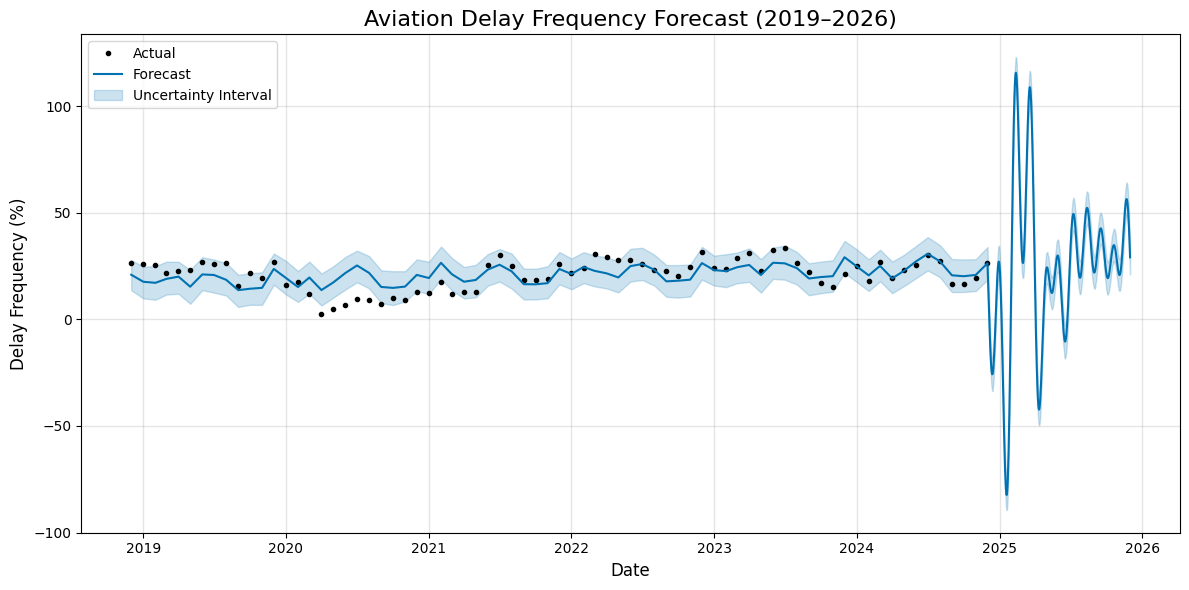

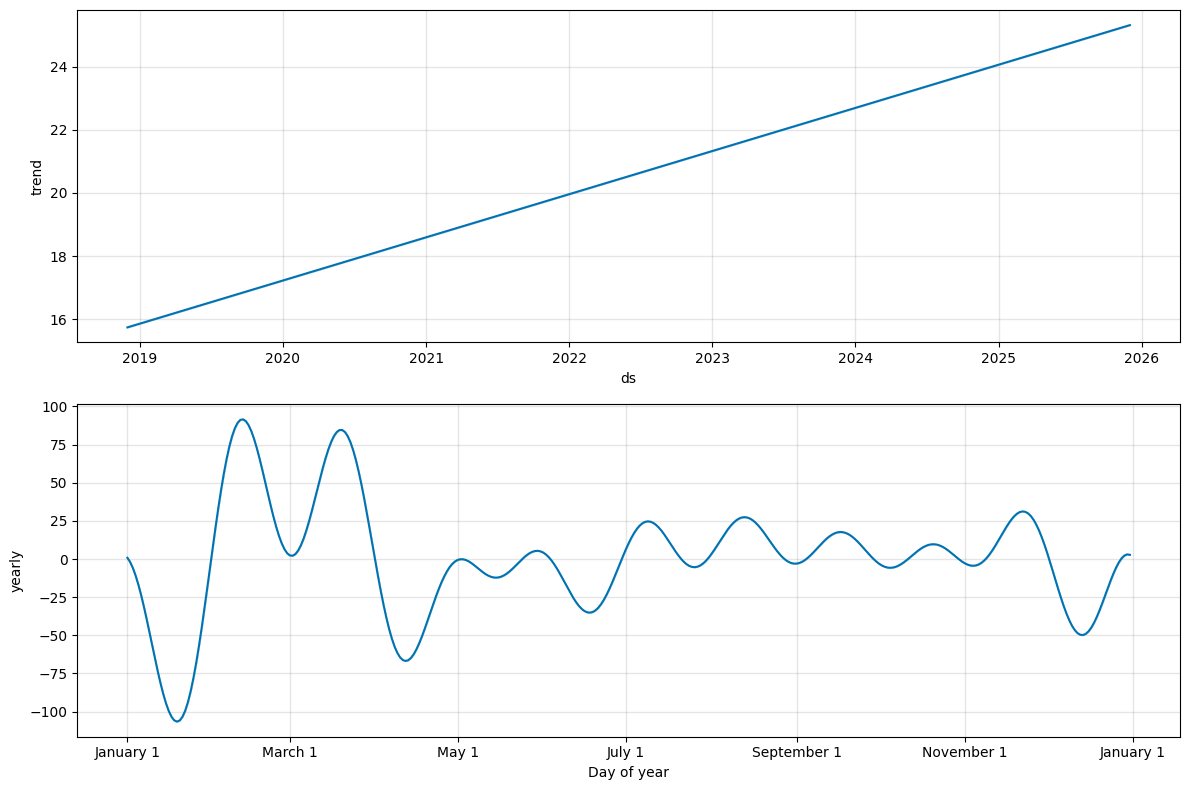

In [101]:
# 1. Prepare your data
# Completed above
# Prophet expects two columns: ds (date) and y (value)

# 2. Initialize and fit the model
m = Prophet()
m.fit(average_delay_frequency)

# 3. Make future dataframe
future = m.make_future_dataframe(periods=365)  # forecast 90 days into the future

# 4. Predict
forecast = m.predict(future)

# 5. Plot
fig1 = m.plot(forecast)
ax = fig1.gca()
ax.set_title("Aviation Delay Frequency Forecast (2019–2026)", fontsize=16)
ax.set_xlabel("Date", fontsize=12)
ax.set_ylabel("Delay Frequency (%)", fontsize=12)
ax.grid(True)
fig1.set_size_inches(12, 6)
plt.tight_layout()
ax.legend(["Actual", "Forecast", "Uncertainty Interval"], loc='upper left', fontsize=10)
#ax.annotate("Post-2025 volatility", xy=(pd.to_datetime('2025-01-01'), 1000),
#            xytext=(pd.to_datetime('2024-01-01'), 1300),
#            arrowprops=dict(facecolor='red', shrink=0.05),
#            fontsize=10)
plt.show()


fig2 = m.plot_components(forecast)
fig2.set_size_inches(12, 8)
plt.tight_layout()
plt.show()
